RLG-DIP Training DIP: 100%|██████████| 2000/2000 [52:44<00:00,  1.58s/epoch, loss=0.00338]


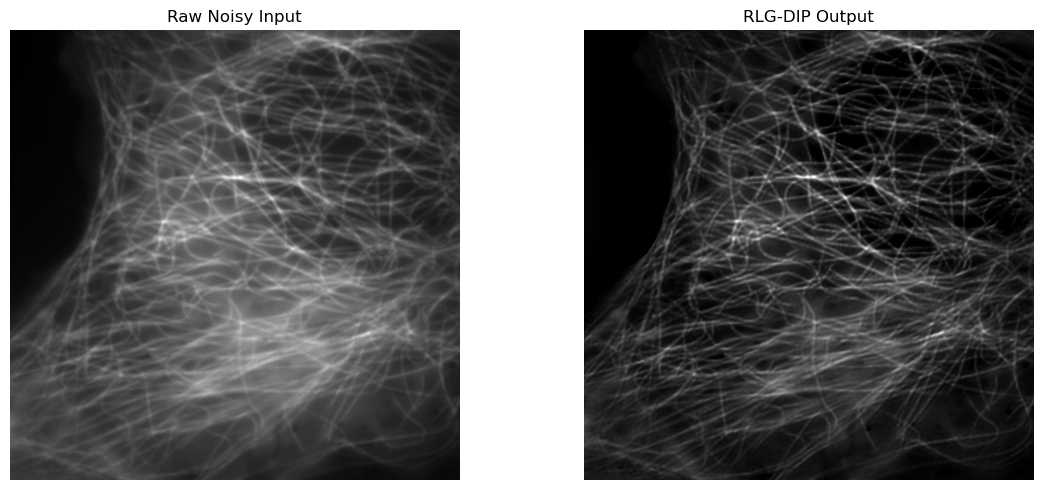

In [ ]:
# -*- coding: utf-8 -*-
import os
import sys
sys.path.append('.')
sys.path.append('./Tools')
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='pywt')
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

from Tools import load_16bit_tiff, save_16bit_tiff, np_to_torch
from Tools import compute_rl_prior
from Tools import DownOTF
from Tools import init_weights
from Tools import get_AiryDisk
from Tools import process_image_with_background_removal
from unet import MediumUNet

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.cuda.FloatTensor if torch.cuda.is_available() else torch.FloatTensor

# ==================== Parameter settings ====================
base_path = r'C:\Users\qxy\Desktop\SDIP-GDIP-AseqDIP\image\RLG-DIPdeconv'
fname_noisy = os.path.join(base_path, 'Micritubules-Raw.tiff')

NA = 1.3
wavelength = 488
sizePixel = 6.26
MA = 100


num_epochs = 2000
inner_iterations = 10
lambda_reg = 1.0
lambda_rl = 1.0
learning_rate = 1e-4
rl_iterations = 10
BACKGROUND_OPTION = 1

# ==================== Load image ====================
raw_noisy_np = load_16bit_tiff(fname_noisy)
img_noisy_np = raw_noisy_np.copy()

img_noisy_np, _ = process_image_with_background_removal(
    img_noisy_np,
    background_option=BACKGROUND_OPTION,
    constant=1.0,
    verbose=True
)

if len(img_noisy_np.shape) == 2:
    img_noisy_np = img_noisy_np[np.newaxis, :, :]

img_noisy_torch = np_to_torch(img_noisy_np).type(dtype)

sizeImage = max(img_noisy_np.shape[1], img_noisy_np.shape[2])

# ==================== Generate PSF / OTF ====================
PSF0, OTF0 = get_AiryDisk(sizeImage, NA, wavelength, sizePixel, MA)

if PSF0.shape[0] != img_noisy_np.shape[1] or PSF0.shape[1] != img_noisy_np.shape[2]:
    import cv2
    PSF0 = cv2.resize(PSF0, (img_noisy_np.shape[2], img_noisy_np.shape[1]))
    PSF0 = PSF0 / np.sum(PSF0)
    psf_centered = np.fft.ifftshift(PSF0)
    otf = np.fft.fft2(psf_centered)
    OTF0 = np.fft.fftshift(otf)

if not np.iscomplexobj(OTF0):
    OTF0 = OTF0.astype(np.complex64)
OTF0_tensor = torch.from_numpy(OTF0[None, None, :, :]).type(torch.complex64).to(device)

# ==================== Compute RL prior ====================
rl_prior = compute_rl_prior(img_noisy_np, PSF0, rl_iterations=rl_iterations)
rl_prior_tensor = np_to_torch(rl_prior).type(dtype).to(device)

# ==================== Define network and optimizer ====================
net = MediumUNet(n_channels=1, n_classes=1).to(device)
init_weights(net, init_type='normal', init_gain=0.02)
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

down_otf_module = DownOTF().to(device)
z_current = img_noisy_torch.clone()
mse = torch.nn.MSELoss().type(dtype)

# ==================== Training loop ====================
epoch_iterator = tqdm(range(num_epochs), desc='RLG-DIP Training DIP', unit='epoch')
for epoch in epoch_iterator:
    for _ in range(inner_iterations):
        optimizer.zero_grad()
        out = net(z_current)

        out_degraded = down_otf_module.forward(out, OTF0_tensor)
        data_loss = mse(out_degraded, img_noisy_torch)
        reg_loss = mse(out, z_current)
        rl_loss = mse(out, rl_prior_tensor)

        total_loss = data_loss + lambda_reg * reg_loss + lambda_rl * rl_loss
        total_loss.backward()
        optimizer.step()

    with torch.no_grad():
        z_current = out.detach().clone()

    epoch_iterator.set_postfix(loss=total_loss.item())

# ==================== Final results display ====================
final_output = z_current.cpu().numpy()[0, 0]

raw_display = raw_noisy_np.copy()
if raw_display.max() > 0:
    raw_display = raw_display / raw_display.max()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw_display, cmap='gray')
plt.axis('off')
plt.title('Raw Noisy Input')

plt.subplot(1, 2, 2)
plt.imshow(final_output, cmap='gray')
plt.axis('off')
plt.title('RLG-DIP Output')
plt.tight_layout()
plt.show()

